# Mapping chimera data on atlas

In [1]:
# Load packages
suppressPackageStartupMessages({
    library(ggplot2)
    library(biomaRt)
    library(BiocParallel)
    library(Matrix)
    library(matrixStats)
    library(scater)
    library(reshape2)
    library(knitr)
    library(scran)
    library(batchelor)
    library(reticulate)
    library(SingleCellExperiment)
    library(data.table)
    library(dplyr)
    library(gridExtra)
})
    ncores = 4
    mcparam = MulticoreParam(workers = ncores)
    register(mcparam)
    BPPARAM = SerialParam()

options(repr.plot.width=15, repr.plot.height=8)

In [80]:
main = "/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/"
out_dir = paste0(main, '07_atlas_mapping/')
plot_dir = paste0(main, '07_atlas_mapping/plots/')
dir.create(out_dir, showWarnings = FALSE)
dir.create(plot_dir, showWarnings = FALSE)

atlas_in = '/rds/project/rds-SDzz0CATGms/users/bt392/mouse/Mixl1_KO/atlas/atlas/'
source(paste0(main, "core_functions.R"))

In [3]:
# UMAP before batch correction
# Running UMAP from python
source_python(paste0(main, 'UMAP_R_to_py.py'))
run_umap = function(pca_in){
    umap = as.data.frame(umap_redu(pca_in))
    colnames(umap) = c('umap_1', 'umap_2')
   # rownames(umap) = big_meta$cell
    return(umap)    
}

In [42]:
umap_theme =  theme(text = element_text(size = 30),
                axis.text.y   = element_blank(),
                axis.text.x   = element_blank(),
                axis.title.y  = element_blank(),
                axis.title.x  = element_blank(),
                axis.ticks = element_blank(),
                legend.position = "none",
                panel.background = element_blank(),
                panel.grid.major = element_blank(), 
                panel.grid.minor = element_blank(),
                panel.border = element_rect(colour = "black", fill=NA, size=1))

In [5]:
# chim
load_data() # load data function written in core_functions.R, alternatively could import files same way as for atlas (genes/meta/count)
meta$cell <- paste0('chim_', meta$cell)

# Atlas 
atlas_counts = readMM(paste0(atlas_in, 'raw_counts.mtx')) # readMM for .mtx input 
atlas_genes = read.table(paste0(atlas_in, 'genes.tsv'), stringsAsFactors = F)
atlas_meta = read.table(paste0(atlas_in, 'meta.tab'), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
atlas_meta$cell <- paste0('atlas_', atlas_meta$cell)

In [16]:
counts = counts(sce)
dimnames(atlas_counts) = list(atlas_genes[,1], atlas_meta$cell)

In [17]:
counts[1:2, 1:2]
dim(meta)
head(meta, 2)
head(genes, 2)
#atlas_counts[1:2, 1:2] # takes to long to load in here for some reason
dim(atlas_meta)
head(atlas_meta, 2)
head(atlas_genes, 2)

2 x 2 sparse Matrix of class "dgCMatrix"
                   cell_1 cell_2
ENSMUSG00000051951      .      .
ENSMUSG00000089699      .      .

,cell,barcode,stage,batch,Sample_name,batch_name,tdTom,sample,doub.density,doublet,stripped,index,umap_1,umap_2,louvain_cluster
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<lgl>,<lgl>,<int>,<chr>,<chr>,<int>
1,chim_cell_1,AAACCCAGTTCTCTAT,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,3,13.9251218125,FALSE,FALSE,1,-0.690803468227386,3.69531440734863,11
2,chim_cell_2,AAACGCTAGTGATTCC,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,3,17.2720353798127,FALSE,FALSE,2,6.81987714767456,10.8029508590698,7


,V1
,<chr>
1,ENSMUSG00000051951
2,ENSMUSG00000089699


,cell,barcode,sample,stage,sequencing.batch,theiler,doub.density,doublet,cluster,cluster.sub,...,haem_gephiY,haem_subclust,endo_gephiX,endo_gephiY,endo_trajectoryName,endo_trajectoryDPT,endo_gutX,endo_gutY,endo_gutDPT,endo_gutCluster
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<dbl>,<lgl>,<int>,<int>,...,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,atlas_cell_1,AAAGGCCTCCACAA,1,E6.5,1,TS9,0.0431142,FALSE,2,4,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,atlas_cell_2,AACAAACTCGCCTT,1,E6.5,1,TS9,1.1297133,FALSE,12,1,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


,V1,V2
,<chr>,<chr>
1,ENSMUSG00000051951,Xkr4
2,ENSMUSG00000089699,Gm1992


In [18]:
# genes shared across datasets
shared_genes = merge(genes, atlas_genes, by='V1')

# filter cells & genes chimera dataset
counts = counts[shared_genes$V1,!c(meta$doublet | meta$stripped)]
meta = meta[!c(meta$doublet | meta$stripped),]

# filter cells & genes atlas dataset
atlas_counts = atlas_counts[shared_genes$V1,!c(atlas_meta$doublet | atlas_meta$stripped)]
atlas_meta = atlas_meta[!c(atlas_meta$doublet | atlas_meta$stripped),]

In [21]:
dim(counts)
dim(atlas_counts)

[1] 29452 27986

[1]  29452 116312

In [22]:
# concatenate count matrices
big_counts = cbind(counts, atlas_counts)
saveRDS(big_counts, file = paste0(out_dir,"big_counts.rds"))

In [23]:
# create big SCE object
big_sce = SingleCellExperiment(assays = list("counts" = big_counts))
saveRDS(big_sce, file = paste0(out_dir,"big_sce.rds"))

In [24]:
big_sce

class: SingleCellExperiment 
dim: 29452 144298 
metadata(0):
assays(1): counts
rownames(29452): ENSMUSG00000000001 ENSMUSG00000000003 ...
  ENSMUSG00000114189 ENSMUSG00000114192
rowData names(0):
colnames(144298): cell_1 cell_2 ... atlas_cell_139330 atlas_cell_139331
colData names(0):
reducedDimNames(0):
altExpNames(0):

### Create metadata 
Match the shared columns into one dataframe for metadata

In [25]:
meta_small = meta %>% select(cell, sample, stage)
meta_small$exp = 'eomes'
atlas_meta_small = atlas_meta %>% select(cell, sample, stage)
atlas_meta_small$exp = 'atlas'
big_meta = rbind(meta_small, atlas_meta_small)
big_meta$index = seq(1:nrow(big_meta))
big_meta$sample = paste0(big_meta$exp, '_', big_meta$sample)

atlas_cols = atlas_meta %>% select(cell, celltype)
chim_cols = meta %>% select(cell, tdTom)
big_meta = merge(big_meta, atlas_cols, all.x=TRUE)
big_meta = merge(big_meta, chim_cols, all.x=TRUE)

big_meta = big_meta[order(big_meta$index), ]

write.csv(big_meta, paste0(out_dir, 'big_meta.csv'), row.names=FALSE)

In [26]:
head(big_meta, 2)

,cell,sample,stage,exp,index,celltype,tdTom
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
116313,chim_cell_1,eomes_3,E8.5,eomes,1,NA,positive
126950,chim_cell_2,eomes_3,E8.5,eomes,2,NA,positive


### process

In [27]:
# calculate sizefactors
clusts = as.numeric(quickCluster(big_sce, method = "igraph", min.size = 100, BPPARAM = mcparam))
min.clust = min(table(clusts))/2
new_sizes = c(floor(min.clust/3), floor(min.clust/2), floor(min.clust))
big_sce = computeSumFactors(big_sce, clusters = clusts, sizes = new_sizes, max.cluster.size = 3000)
write.table(sizeFactors(big_sce), quote = F, col.names = F, row.names = F, file = paste0(out_dir,"sizefactors_big.tab"))

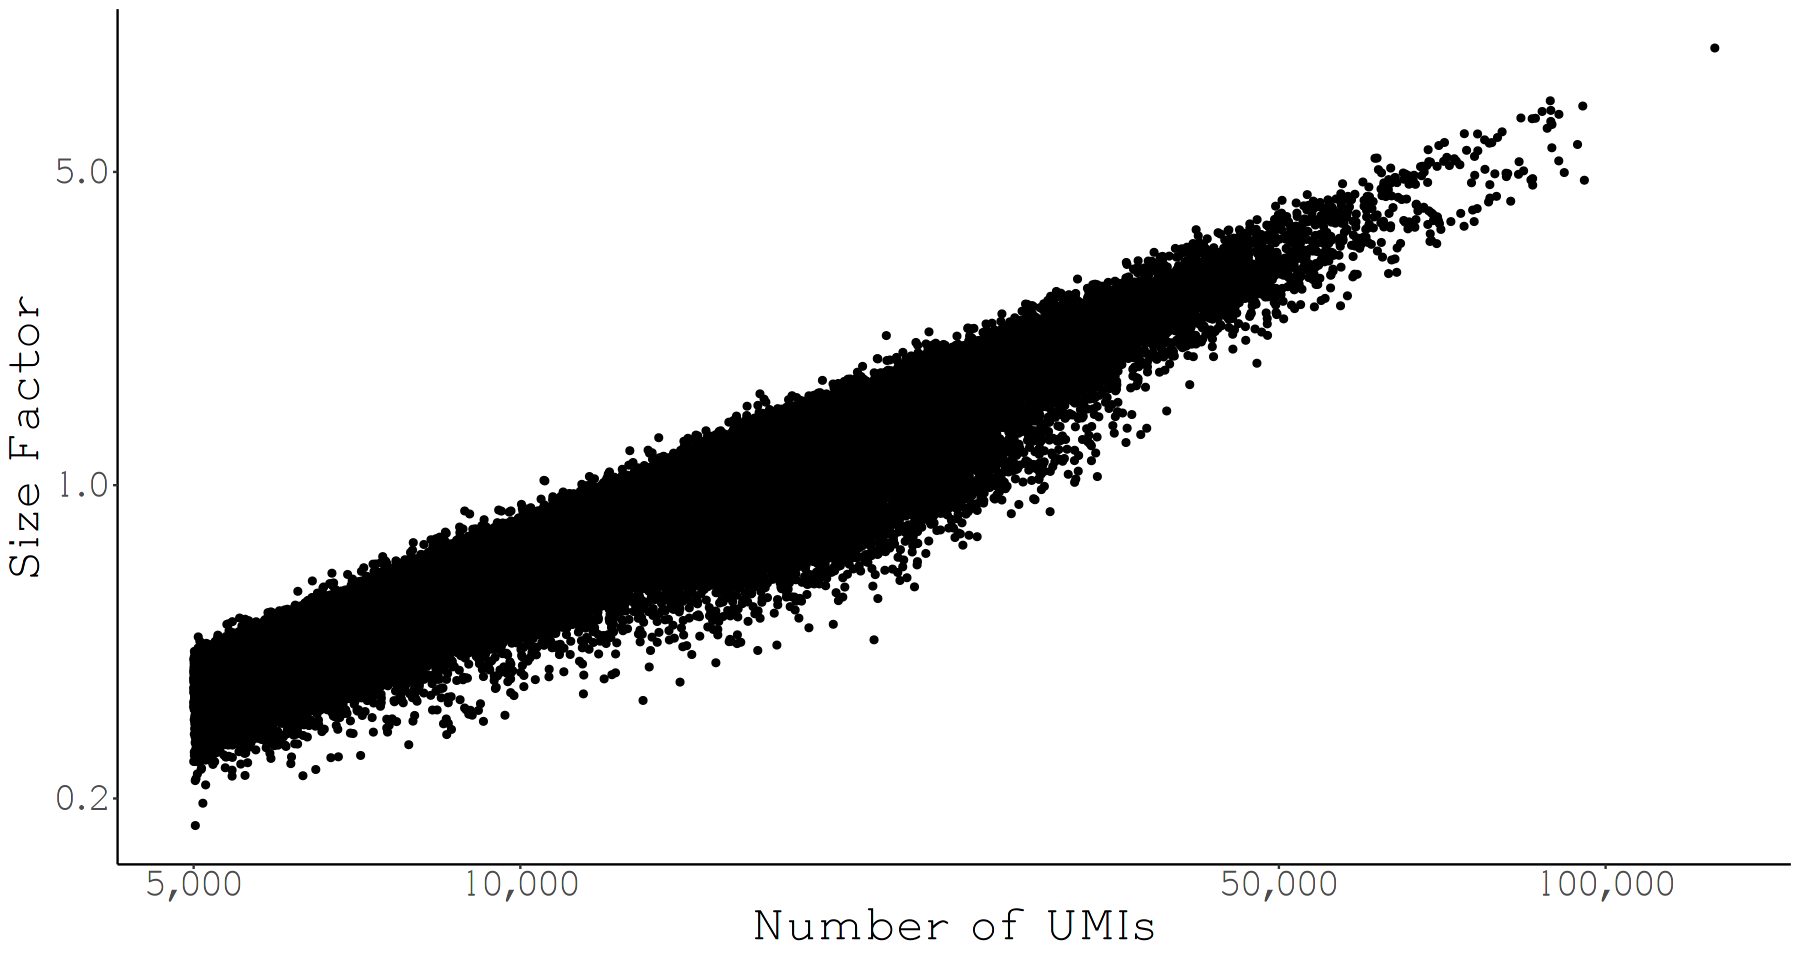

In [28]:
lib.sizes = Matrix::colSums(counts(big_sce))
ggplot(data = data.frame(X = lib.sizes, Y = sizeFactors(big_sce)),
              mapping = aes(x = X, y = Y)) +
  geom_point() +
  scale_x_log10(breaks = c(5000, 10000, 50000, 100000), labels = c("5,000", "10,000", "50,000", "100,000") ) +
  scale_y_log10(breaks = c(0.2, 1, 5)) +
  labs(x = "Number of UMIs", y = "Size Factor") + 
    theme_classic() + 
    theme(text = element_text(size=30))

In [29]:
# Normalize
#sfs = read.table(paste0(out_dir,"sizefactors_big.tab"), stringsAsFactors = F)[,1]
#sizeFactors(big_sce) = sfs
big_sce = scater::logNormCounts(big_sce)

# save normalized sce
saveRDS(big_sce, file = paste0(out_dir,"big_sce_norm.rds"))

In [30]:
big_sce

class: SingleCellExperiment 
dim: 29452 144298 
metadata(0):
assays(2): counts logcounts
rownames(29452): ENSMUSG00000000001 ENSMUSG00000000003 ...
  ENSMUSG00000114189 ENSMUSG00000114192
rowData names(0):
colnames(144298): cell_1 cell_2 ... atlas_cell_139330 atlas_cell_139331
colData names(1): sizeFactor
reducedDimNames(0):
altExpNames(0):

## Batch correction

### Cosine normalisation & PCA

In [31]:
#big_sce = readRDS(paste0(out_dir,"big_sce_norm.rds"))

In [32]:
#big_meta = read.csv(paste0(out_dir, 'big_meta.csv'))

In [33]:
hvgs = getHVGs(big_sce)
write.csv(hvgs, file =  paste0(out_dir,"big_hvgs.csv"))

In [34]:
head(hvgs)

[1] "ENSMUSG00000000031" "ENSMUSG00000000093" "ENSMUSG00000000094"
[4] "ENSMUSG00000000120" "ENSMUSG00000000171" "ENSMUSG00000000184"

In [35]:
#### Cosine normalisation ##### 
# add metadata combining stage & sample
big_meta$comb <- paste0(big_meta$stage, "_", big_meta$sample)

# extract counts for each combination
mat_temp = logcounts(big_sce)
mat = mat_temp[hvgs,]

# seperate count matrices based on combination
comb <- list()
for(i in unique(big_meta$comb)){
    comb[[i]] <- mat[, big_meta$comb == i]
}
paste0('nr of combinations: ', length(comb))

# cosine normalize
comb_cos <- list()
for(i in 1:length(comb)){
    comb_cos[[i]] <- cosineNorm(comb[[i]])
}

[1] "nr of combinations: 44"

In [36]:
#### calculate PCs #####
big_pca = multiBatchPCA(comb_cos ,BPPARAM = BPPARAM,d = 50)

In [37]:
#saveRDS(big_pca, file=paste0(out_dir, 'uncorrected_PCs_multibatch.rds'))
big_pca <- do.call(rbind, big_pca)
saveRDS(big_pca, file=paste0(out_dir, 'uncorrected_PCs.rds'))

### Batch correction

In [45]:
big_pca <- readRDS(paste0(out_dir, 'uncorrected_PCs.rds'))
big_meta = read.csv(paste0(out_dir, 'big_meta.csv'))

In [46]:
tail(big_pca,2)

atlas_cell_139330,0.01836977,-0.13915718,0.405890268,0.25037224,0.16803344,-0.0002414884,-0.02991376,-0.07334318,0.060284575,-0.01864150,...,-0.02531119,-0.01042992,-0.0001032411,0.019939422,-0.005612728,0.02027484,-0.002691241,-0.007731481,-0.0052399049,-0.009467472
atlas_cell_139331,-0.12114493,0.03417272,0.007691914,0.04194592,0.07261253,-0.0083813741,-0.11976616,0.06467700,0.004430225,0.04413303,...,0.03198894,-0.02652224,0.0305252883,0.005876734,0.000725161,0.04596084,0.027060114,0.010002072,-0.0009937367,-0.005188989


In [ ]:
plot_umap = function(umap){
p1 = ggplot(umap, aes(umap_1, umap_2, col= as.factor(big_meta$celltype))) + 
        scale_colour_manual(values = celltype_colours, name = "celltype") +
        geom_point(alpha = 0.2) + 
        ggtitle('Celltype') + 
        umap_theme


p2 = ggplot(umap, aes(umap_1, umap_2, col= as.factor(big_meta$sample))) + 
        geom_point(alpha = 0.2) + 
        ggtitle('Sample') + 
        umap_theme
    
p3 = ggplot(umap[big_meta$exp=='eomes',], aes(umap_1, umap_2, col=big_meta[big_meta$exp=='eomes',]$tdTom)) + 
        geom_point(data=umap[!big_meta$exp=='eomes',], alpha = 0.2, col = 'grey') + 
        geom_point(alpha = 0.2) + 
        scale_colour_manual(values = c('negative' = 'black', 'positive' = 'red'), name = "Tomato") +
        ggtitle('Origin') + 
        umap_theme
    
    
    grid.arrange(p3, p1, p2, ncol = 3)
}

Warning message:
“Removed 27986 rows containing missing values (geom_point).”


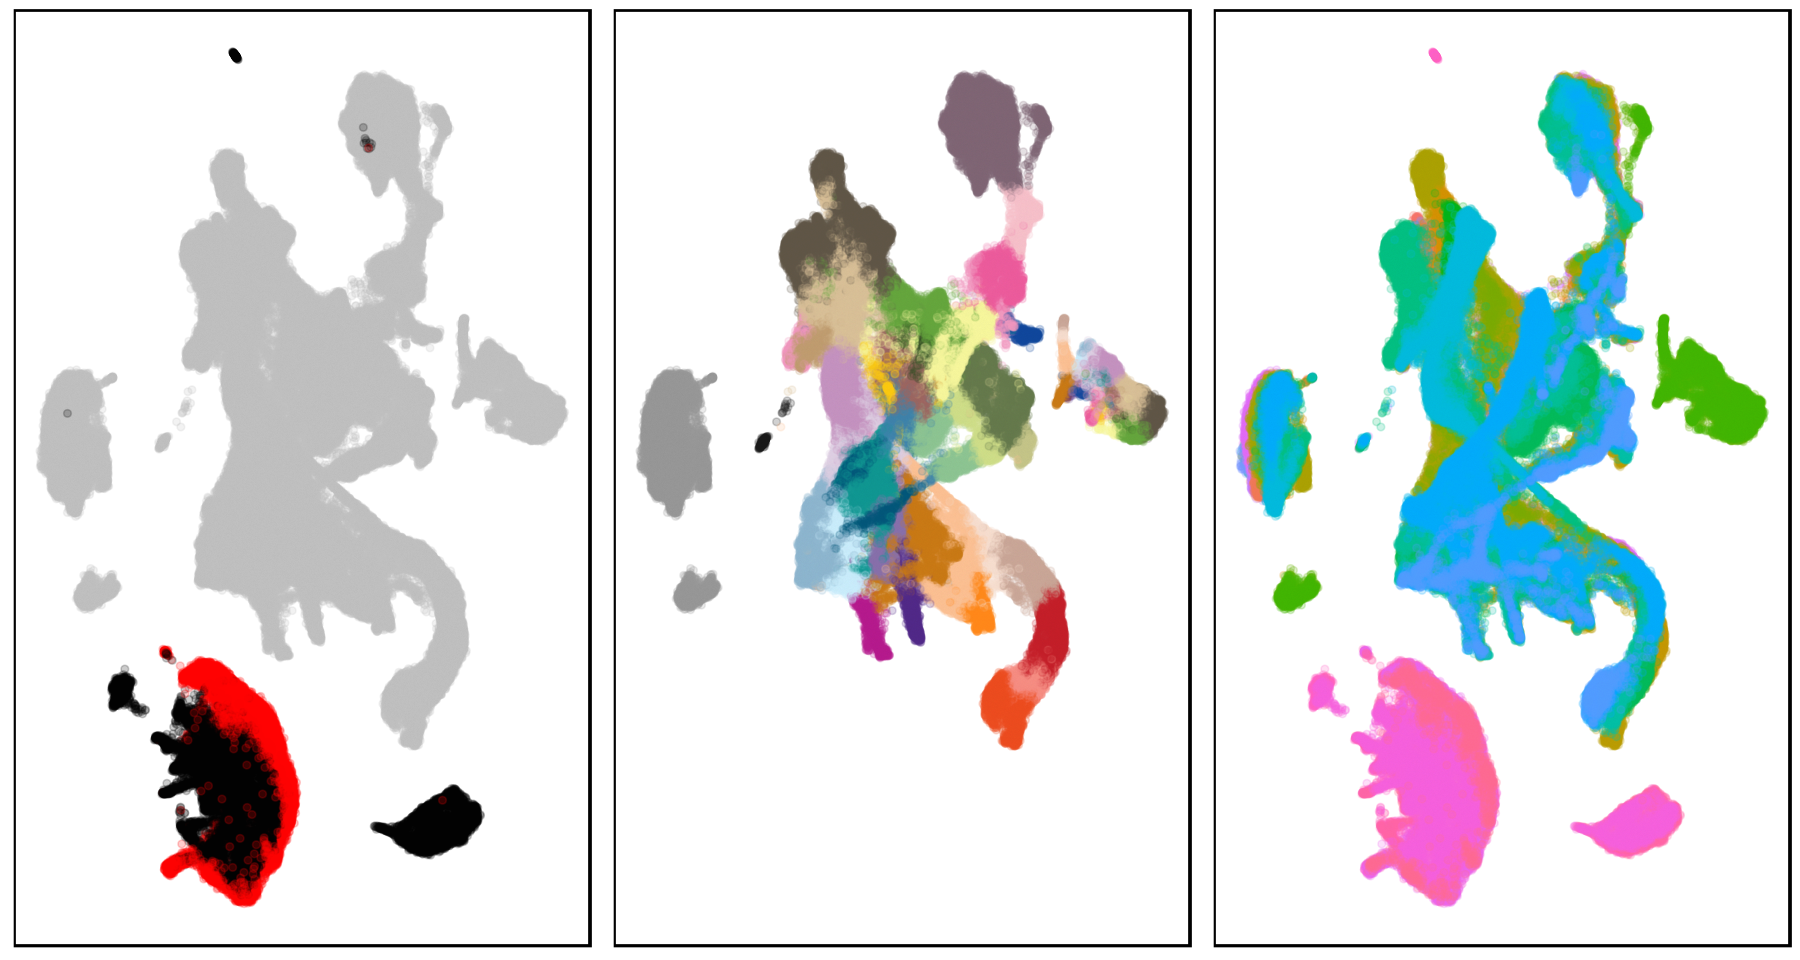

In [49]:
#big_pca = big_pca[,1:5] ##### TEST!!
umap = run_umap(big_pca)
plot_umap(umap)

In [50]:
ggsave(paste0(plot_dir, 'UMAPs_before_correction.png'), 
       plot = plot_umap(umap), 
       device = 'png',
       width = 12,
       height = 6,
       dpi = 300)

Warning message:
“Removed 27986 rows containing missing values (geom_point).”


In [9]:
big_meta$stage[which(big_meta$exp=='eomes')] <- paste0(big_meta$stage, '_', big_meta$exp)

Warning message in big_meta$stage[which(big_meta$exp == "eomes")] <- paste0(big_meta$stage, :
“number of items to replace is not a multiple of replacement length”


In [10]:
#### reducedMNN preparation ##### (run in next cell)
set.seed(42)
# over several iterations 

# order of batch corrections --> input chimaera as seperate timepoint to make looping easier
#### This way chimaera's will still be batch corrected separately from atlas.
order_df = big_meta[!duplicated(big_meta$sample), c("stage", "sample")]
order_df$ncells = sapply(order_df$sample, function(x) sum(big_meta$sample == x))
order_df$stage = factor(order_df$stage,
                          levels = rev(c("E8.5", 
                                         "E8.25", 
                                         "E8.0", 
                                         "E7.75", 
                                         "E7.5", 
                                         "E7.25", 
                                         "mixed_gastrulation", 
                                         "E7.0", 
                                         "E6.75", 
                                         "E6.5",
                                         "E8.5_chim"))) # Chimaera last!
order_df = order_df[order(order_df$stage, order_df$ncells, decreasing = TRUE),]
order_df$stage = as.character(order_df$stage)
order_df$comb <- paste0(order_df$stage, "_", order_df$sample)

# defenitions for creating nested lists                         
timepoints = big_meta$stage
samples = big_meta$sample
timepoint_order = order_df$stage
sample_order = order_df$sample

#create nested list
  pc_list = lapply(unique(timepoints), function(tp){
    sub_pc = big_pca[timepoints == tp, , drop = FALSE]
    sub_samp = samples[timepoints == tp]
    list = lapply(unique(sub_samp), function(samp){
     sub_pc[sub_samp == samp, , drop = FALSE]
    })
    names(list) = unique(sub_samp)
    return(list)
  })

  names(pc_list) = unique(timepoints)

  #arrange to match timepoint order
  pc_list = pc_list[order(match(names(pc_list), timepoint_order))]
  pc_list = lapply(pc_list, function(x){
    x[order(match(names(x), sample_order))]
  })


In [11]:
#perform corrections within atlas timepoints & eomes
correct_list = lapply(pc_list, function(x){
if(length(x) > 1){
  return(do.call(reducedMNN, c(x, BPPARAM = BPPARAM))$corrected)
} else {
  return(x[[1]])
}
})

In [16]:
#perform correction over atlas (list elements 1 - 10)
correct_atlas = do.call(reducedMNN, c(correct_list[c(1:10)], BPPARAM = BPPARAM))$corrected

In [28]:
# rownames of chimera cells should be 'chim_cell_x' instead of 'cell_x'
# This should've already been called like this before count matrices were merged
# but I forgot so will correct it here for this once....
rownames(correct_list[[11]]) = paste0('chim_', rownames(correct_list[[11]]))

In [30]:
# correct between atlas and chimera
exp_corr_list = list(correct_atlas, correct_list[[11]])
correct = do.call(reducedMNN, c(exp_corr_list, BPPARAM = BPPARAM))$corrected

In [32]:
correct = correct[match(big_meta$cell, rownames(correct)),] # edited

In [36]:
head(big_meta,2)
head(correct,2)

tail(big_meta,2)
tail(correct,2)

,cell,sample,stage,exp,index,celltype,tdTom
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
1,chim_cell_1,eomes_3,E8.5_eomes,eomes,1,NA,positive
2,chim_cell_2,eomes_3,E8.5_eomes,eomes,2,NA,positive


chim_cell_1,-0.07425758,0.004993292,-0.009314652,0.067748275,0.006875929,0.008549112,-0.11901411,0.046386316,0.008623807,0.01826835,...,0.03225517,0.0043542844,0.016671152,0.012813270,-0.020803777,0.009284795,0.01815313,-0.01894167,-0.004728866,-0.006338122
chim_cell_2,-0.10672898,-0.067166940,-0.067018141,0.001921664,0.115145086,-0.156064487,-0.01894693,-0.008659954,0.008839002,-0.02981259,...,-0.01976885,-0.0008154875,0.007282246,-0.001326223,0.007456151,0.041643511,0.01271758,-0.01157842,-0.002678999,0.034806856


,cell,sample,stage,exp,index,celltype,tdTom
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
144297,atlas_cell_139330,atlas_37,E8.5,atlas,144297,Erythroid3,NA
144298,atlas_cell_139331,atlas_37,E8.5,atlas,144298,Forebrain/Midbrain/Hindbrain,NA


atlas_cell_139330,0.001958472,-0.13507580,0.37128732,0.22886690,0.14737798,-0.003576011,-0.03025849,-0.04679544,0.0467813323,-0.03779009,...,-0.02855980,0.01856108,0.006370109,0.022438362,0.001961472,0.01988051,-0.009222227,-0.001362081,-0.003420585,0.0006720557
atlas_cell_139331,-0.123362591,0.00419878,0.01033313,0.03419589,0.04877573,-0.006804591,-0.12366006,0.07759784,-0.0002760525,0.03213857,...,0.02858226,-0.01440917,0.038088121,0.004248916,0.004355460,0.04346772,0.021033471,0.006466424,0.003381084,-0.0057258039


In [37]:
pca_after = as.data.frame(correct)
pca_after$cell = rownames(pca_after)
write.csv(correct, file =  paste0(out_dir,"corrected_PCs.csv"),row.names=FALSE)
#pca_after = pc_after[, -1]

In [55]:
correct = read.csv(paste0(out_dir,"corrected_PCs.csv"), row.names=1)
big_meta = read.csv(paste0(out_dir, 'big_meta.csv'))

Warning message:
“Removed 27986 rows containing missing values (geom_point).”


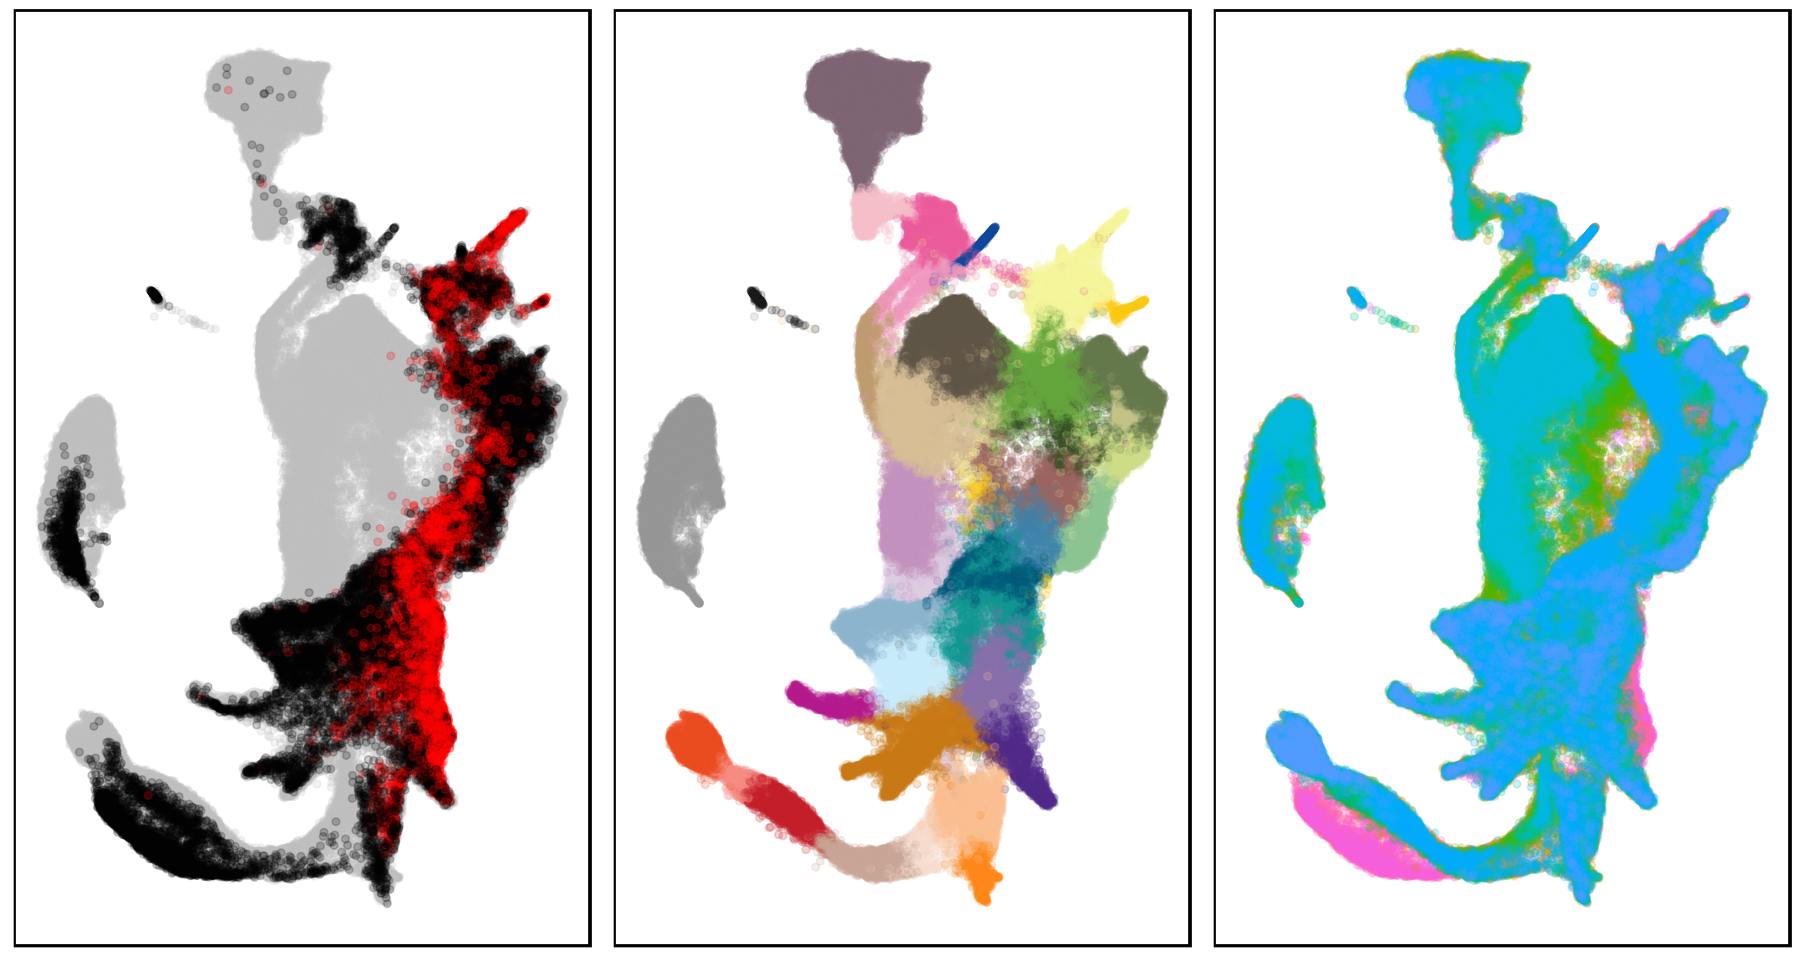

In [56]:
umap = run_umap(correct)
plot_umap(umap)

In [48]:
ggsave(paste0(plot_dir, 'UMAPs_after_correction.png'), 
       plot = plot_umap(umap), 
       device = 'png',
       width = 12,
       height = 6,
       dpi = 300)

Warning message:
“Removed 27986 rows containing missing values (geom_point).”


In [57]:
big_meta = cbind(big_meta, umap)

In [11]:
pca_after = as.data.frame(correct)

In [12]:
correct_atlas = pca_after[big_meta$exp=='atlas',]
atlas_meta = big_meta[big_meta$exp=='atlas',]

correct_map = pca_after[!big_meta$exp=='atlas',]
map_meta = big_meta[!big_meta$exp=='atlas',]

In [32]:
## Code for mapping:

getmode <- function(v, dist) {
  tab = table(v)
  #if tie, break to shortest distance
  if(sum(tab == max(tab)) > 1){
    tied = names(tab)[tab == max(tab)]
    sub = dist[v %in% tied]
    names(sub) = v[v %in% tied]
    return(names(sub)[which.min(sub)])
  } else {
    return(names(tab)[which.max(tab)])
  }
}

mnnMap = function(atlas_pca, atlas_meta, map_pca, map_meta, k_map = 10){
  require(BiocNeighbors)
  require(scran)
  
  knns = BiocNeighbors::queryKNN(correct_atlas, correct_map, k = k_map, get.index = TRUE, get.distance = FALSE)
  
  #get closest k matching cells
  k.mapped = t(apply(knns$index, 1, function(x) atlas_meta$cell[x]))
  celltypes = t(apply(k.mapped, 1, function(x) atlas_meta$celltype[match(x, atlas_meta$cell)]))
  stages = t(apply(k.mapped, 1, function(x) atlas_meta$stage[match(x, atlas_meta$cell)]))
  celltype.mapped = apply(celltypes, 1, function(x) getmode(x, 1:length(x)))
  stage.mapped = apply(stages, 1, function(x) getmode(x, 1:length(x)))
  
  out = lapply(1:length(celltype.mapped), function(x){
    list(cells.mapped = k.mapped[x,],
         celltype.mapped = celltype.mapped[x],
         stage.mapped = stage.mapped[x])
  })
  
  names(out) = map_meta$cell

  return(out)
  
}

In [33]:
# Perform mapping:
mapping = mnnMap(correct_atlas, atlas_meta, correct_map, map_meta, k_map = 10)

  cn = names(mapping) # remove 
  ct = sapply(mapping, function(x) x$celltype.mapped)
  st = sapply(mapping, function(x) x$stage.mapped)
  closest = sapply(mapping, function(x) x$cells.mapped[1])
  
  out = data.frame(cell = cn, celltype.mapped = ct, stage.mapped = st, closest.cell = closest)
                   
# save mapped celltypes
write.csv(out, paste0(out_dir, 'chimaera_mapped_celltypes.csv')) 

In [58]:
big_meta = merge(big_meta, out, by='cell', all=TRUE)
big_meta = big_meta[order(big_meta$index),]

In [59]:
write.csv(big_meta, paste0(out_dir, 'big_meta_mapping.csv')) 

In [60]:
head(big_meta,2)

,cell,sample,stage,exp,index,celltype,tdTom,umap_1,umap_2,celltype.mapped,stage.mapped,closest.cell
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
116313,chim_cell_1,eomes_3,E8.5,eomes,1,NA,positive,15.47548,7.4767385,Rostral neurectoderm,E8.0,atlas_cell_128991
126950,chim_cell_2,eomes_3,E8.5,eomes,2,NA,positive,11.81578,-0.3393915,Intermediate mesoderm,E8.0,atlas_cell_130173


In [19]:
head(big_meta,2)

,cell,sample,stage,exp,index,celltype,tdTom,umap_1,umap_2,celltype.mapped,stage.mapped,closest.cell
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
116313,chim_cell_1,eomes_3,E8.5,eomes,1,NA,positive,15.47548,7.4767385,Rostral neurectoderm,E8.0,atlas_cell_128991
126950,chim_cell_2,eomes_3,E8.5,eomes,2,NA,positive,11.81578,-0.3393915,Intermediate mesoderm,E8.0,atlas_cell_130173


Warning message:
“Removed 27986 rows containing missing values (geom_point).”
Warning message:
“Removed 116312 rows containing missing values (geom_point).”


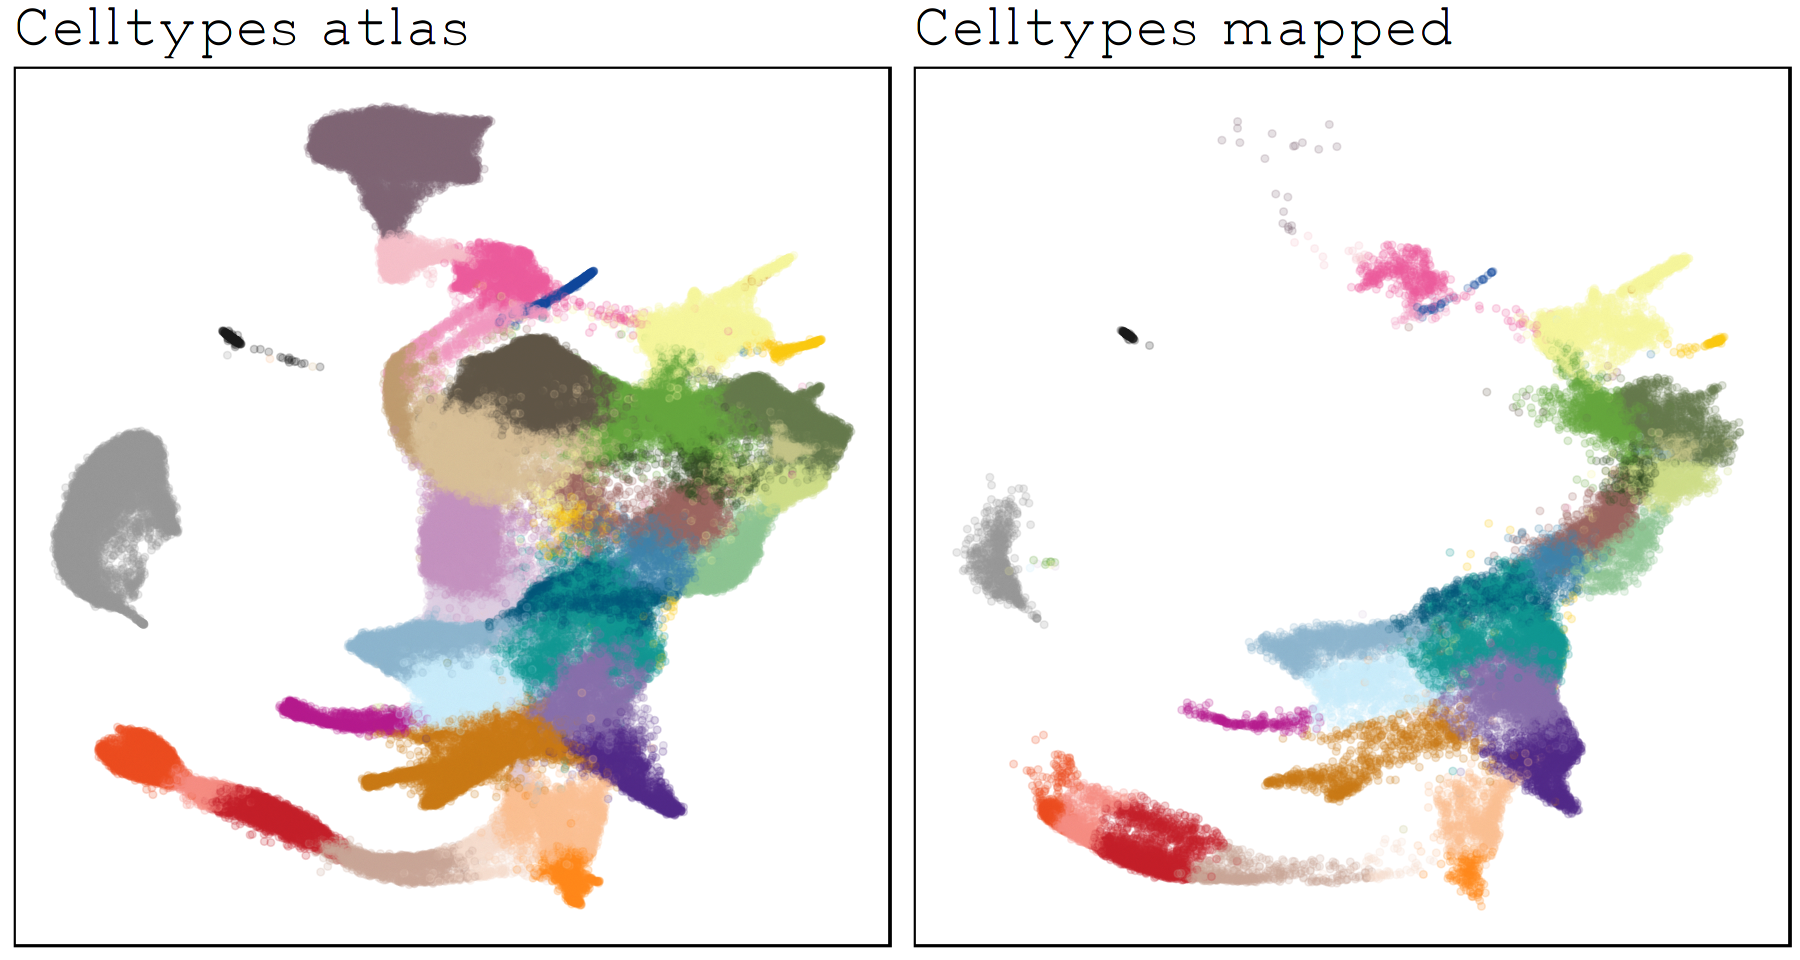

In [61]:
p1 = ggplot(big_meta, aes(umap_1, umap_2, col= as.factor(celltype))) + 
        scale_colour_manual(values = celltype_colours, name = "celltype") +
        geom_point(alpha = 0.2) + 
        ggtitle('Celltypes atlas') + 
        umap_theme

p2 = ggplot(big_meta, aes(umap_1, umap_2, col= as.factor(celltype.mapped))) + 
        scale_colour_manual(values = celltype_colours, name = "celltype") +
        geom_point(alpha = 0.2) + 
        ggtitle('Celltypes mapped') + 
        umap_theme

grid.arrange(p1, p2, ncol=2)

In [62]:
ggsave(paste0(plot_dir, 'UMAP_celltype_mapping.png'), 
       plot = grid.arrange(p1, p2, ncol=2), 
       device = 'png',
       width = 8,
       height = 6,
       dpi = 300)

Warning message:
“Removed 27986 rows containing missing values (geom_point).”
Warning message:
“Removed 116312 rows containing missing values (geom_point).”


Warning message:
“Removed 27986 rows containing missing values (geom_point).”
Warning message:
“Removed 15935 rows containing missing values (geom_point).”


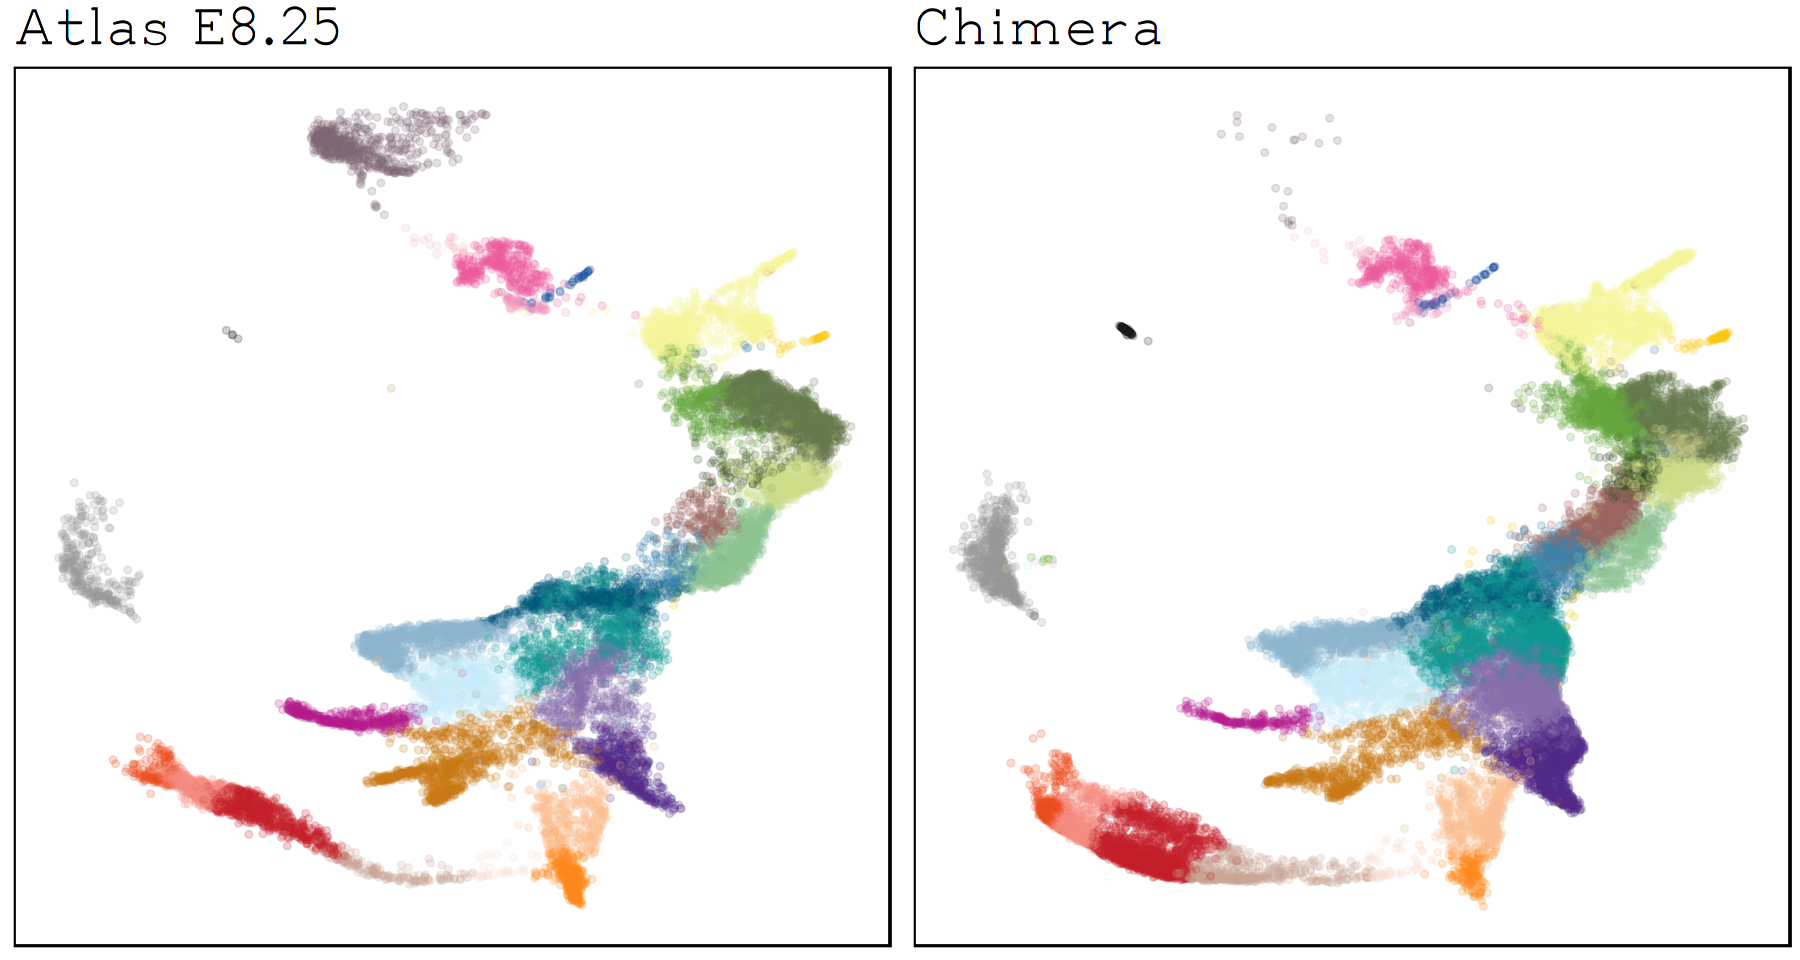

In [64]:
keep = which(big_meta$exp=='eomes' | big_meta$stage == 'E8.25')

p1 = ggplot(big_meta[keep,], aes(umap_1, umap_2, col= as.factor(big_meta[keep,]$celltype))) + 
        scale_colour_manual(values = celltype_colours, name = "celltype") +
        geom_point(alpha = 0.2) + 
        ggtitle('Atlas E8.25') + 
        umap_theme

p2 = ggplot(big_meta[keep,], aes(umap_1, umap_2, col= as.factor(big_meta[keep,]$celltype.mapped))) + 
        scale_colour_manual(values = celltype_colours, name = "celltype") +
        geom_point(alpha = 0.2) + 
        ggtitle('Chimera') +
        umap_theme

grid.arrange(p1, p2, ncol=2)

In [65]:
ggsave(paste0(plot_dir, 'UMAP_celltype_mapping_E8_25.png'), 
       plot = grid.arrange(p1, p2, ncol=2), 
       device = 'png',
       width = 8,
       height = 6,
       dpi = 300)

Warning message:
“Removed 27986 rows containing missing values (geom_point).”
Warning message:
“Removed 15935 rows containing missing values (geom_point).”


Warning message:
“Removed 116312 rows containing missing values (geom_point).”
Warning message:
“Removed 116312 rows containing missing values (geom_point).”


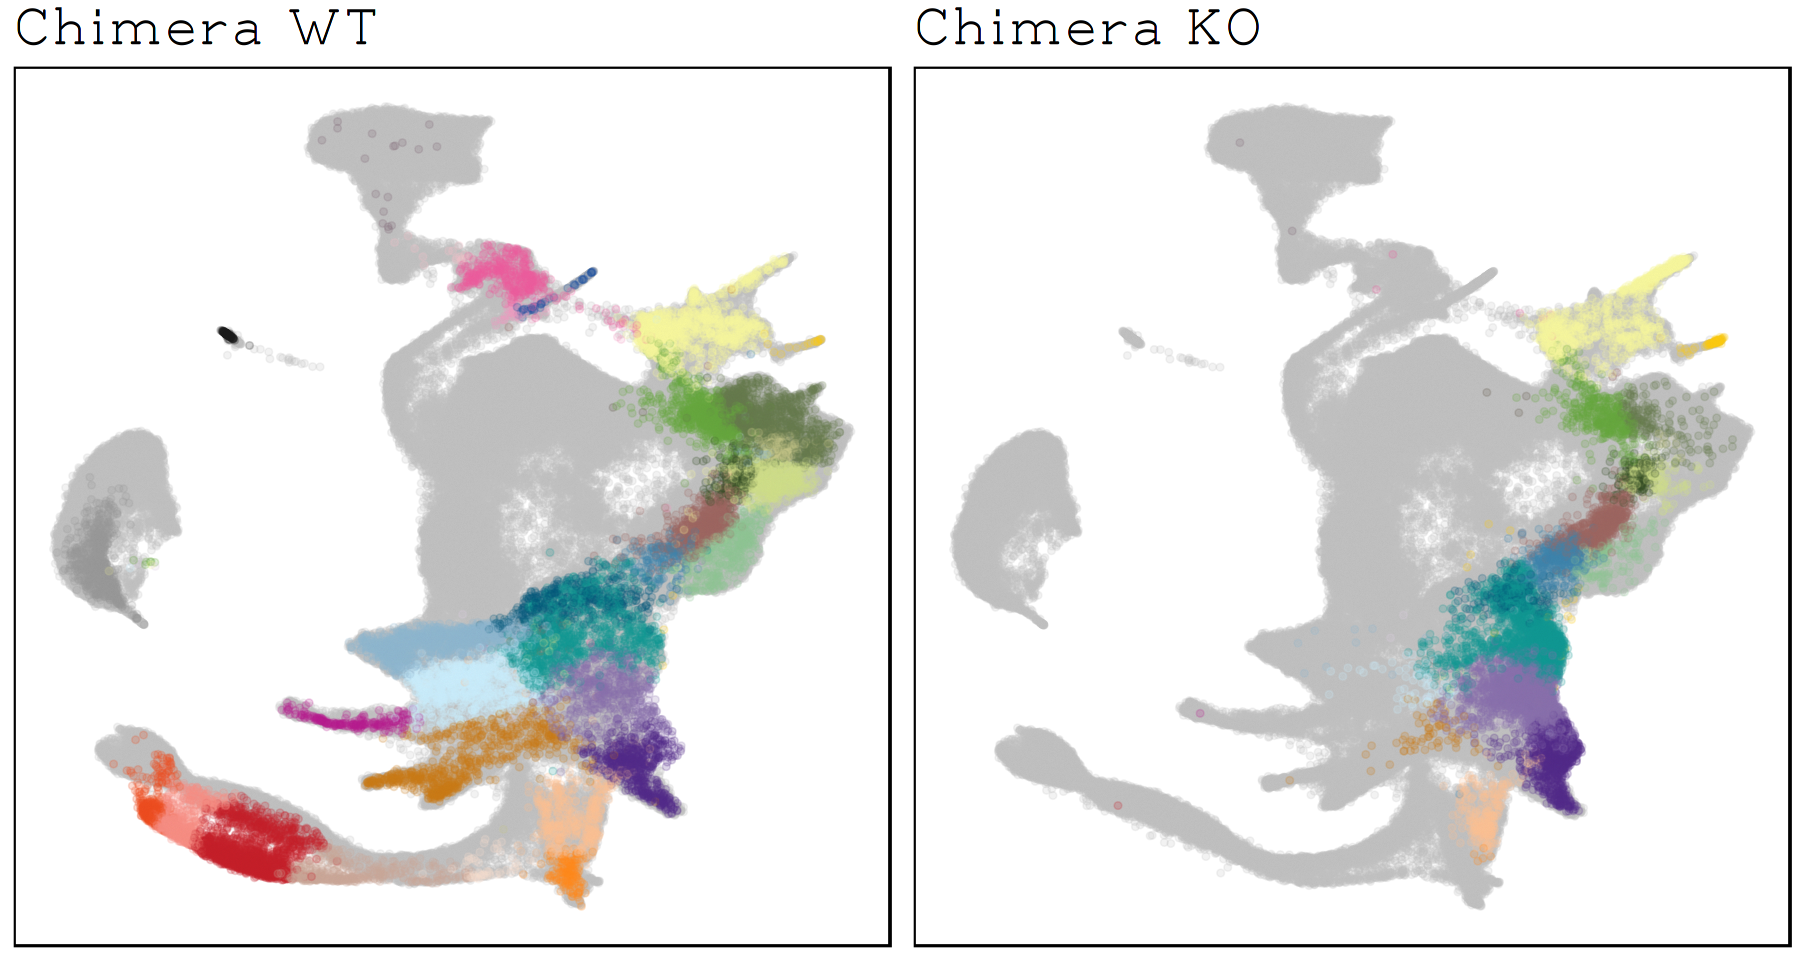

In [69]:
p1 = ggplot(big_meta[big_meta$tdTom=='negative',], aes(umap_1, umap_2, col= as.factor(big_meta[big_meta$tdTom=='negative',]$celltype.mapped))) + 
        scale_colour_manual(values = celltype_colours, name = "celltype") +
        geom_point(data=big_meta[!big_meta$exp=='eomes',], alpha = 0.2, col = 'grey') + 
        geom_point(alpha = 0.2) + 
        ggtitle('Chimera WT') + 
        umap_theme

p2 = ggplot(big_meta[big_meta$tdTom=='positive',], aes(umap_1, umap_2, col= as.factor(big_meta[big_meta$tdTom=='positive',]$celltype.mapped))) + 
        scale_colour_manual(values = celltype_colours, name = "celltype") +
        geom_point(data=big_meta[!big_meta$exp=='eomes',], alpha = 0.2, col = 'grey') + 
        geom_point(alpha = 0.2) + 
        ggtitle('Chimera KO') +
        umap_theme

grid.arrange(p1, p2, ncol=2)

In [70]:
ggsave(paste0(plot_dir, 'UMAP_WT_KO_comparison.png'), 
       plot = grid.arrange(p1, p2, ncol=2), 
       device = 'png',
       width = 8,
       height = 6,
       dpi = 300)

Warning message:
“Removed 116312 rows containing missing values (geom_point).”
Warning message:
“Removed 116312 rows containing missing values (geom_point).”


In [122]:
# plot original atlas projection to make comprehensible
atlas_meta = read.table(paste0(atlas_in, 'meta.tab'), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
atlas_meta$cell <- paste0('atlas_', atlas_meta$cell)

atlas_umap <- atlas_meta[, c('cell', 'umapX', 'umapY')]
big_meta <- merge(big_meta, atlas_umap, by='cell', all.x=TRUE)[, union(names(big_meta), names(atlas_umap))] # last part just to keep column order
colnames(atlas_umap) <- c('closest.cell', 'umapX.mapped', 'umapY.mapped')
big_meta <- merge(big_meta, atlas_umap, by='closest.cell', all.x=TRUE)[, union(names(big_meta), names(atlas_umap))] # last part just to keep column order
big_meta = big_meta[order(big_meta$index),]

In [ ]:
#### This is the final version of the metadata! #####
write.csv(big_meta, paste0(out_dir, 'big_meta_complete.csv'), row.names=FALSE)

In [123]:
head(big_meta, 2)

,cell,sample,stage,exp,index,celltype,tdTom,umap_1,umap_2,celltype.mapped,stage.mapped,closest.cell,umapX,umapY,umapX.mapped,umapY.mapped
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
7682,chim_cell_1,eomes_3,E8.5,eomes,1,NA,positive,15.47548,7.4767385,Rostral neurectoderm,E8.0,atlas_cell_128991,NA,NA,-5.052783,-5.126286
8413,chim_cell_2,eomes_3,E8.5,eomes,2,NA,positive,11.81578,-0.3393915,Intermediate mesoderm,E8.0,atlas_cell_130173,NA,NA,1.394493,3.372258


Warning message:
“Removed 23019 rows containing missing values (geom_point).”
Warning message:
“Removed 23019 rows containing missing values (geom_point).”
Warning message:
“Removed 116312 rows containing missing values (geom_point).”
Warning message:
“Removed 116312 rows containing missing values (geom_point).”
Warning message:
“Removed 116312 rows containing missing values (geom_point).”
Warning message:
“Removed 116312 rows containing missing values (geom_point).”


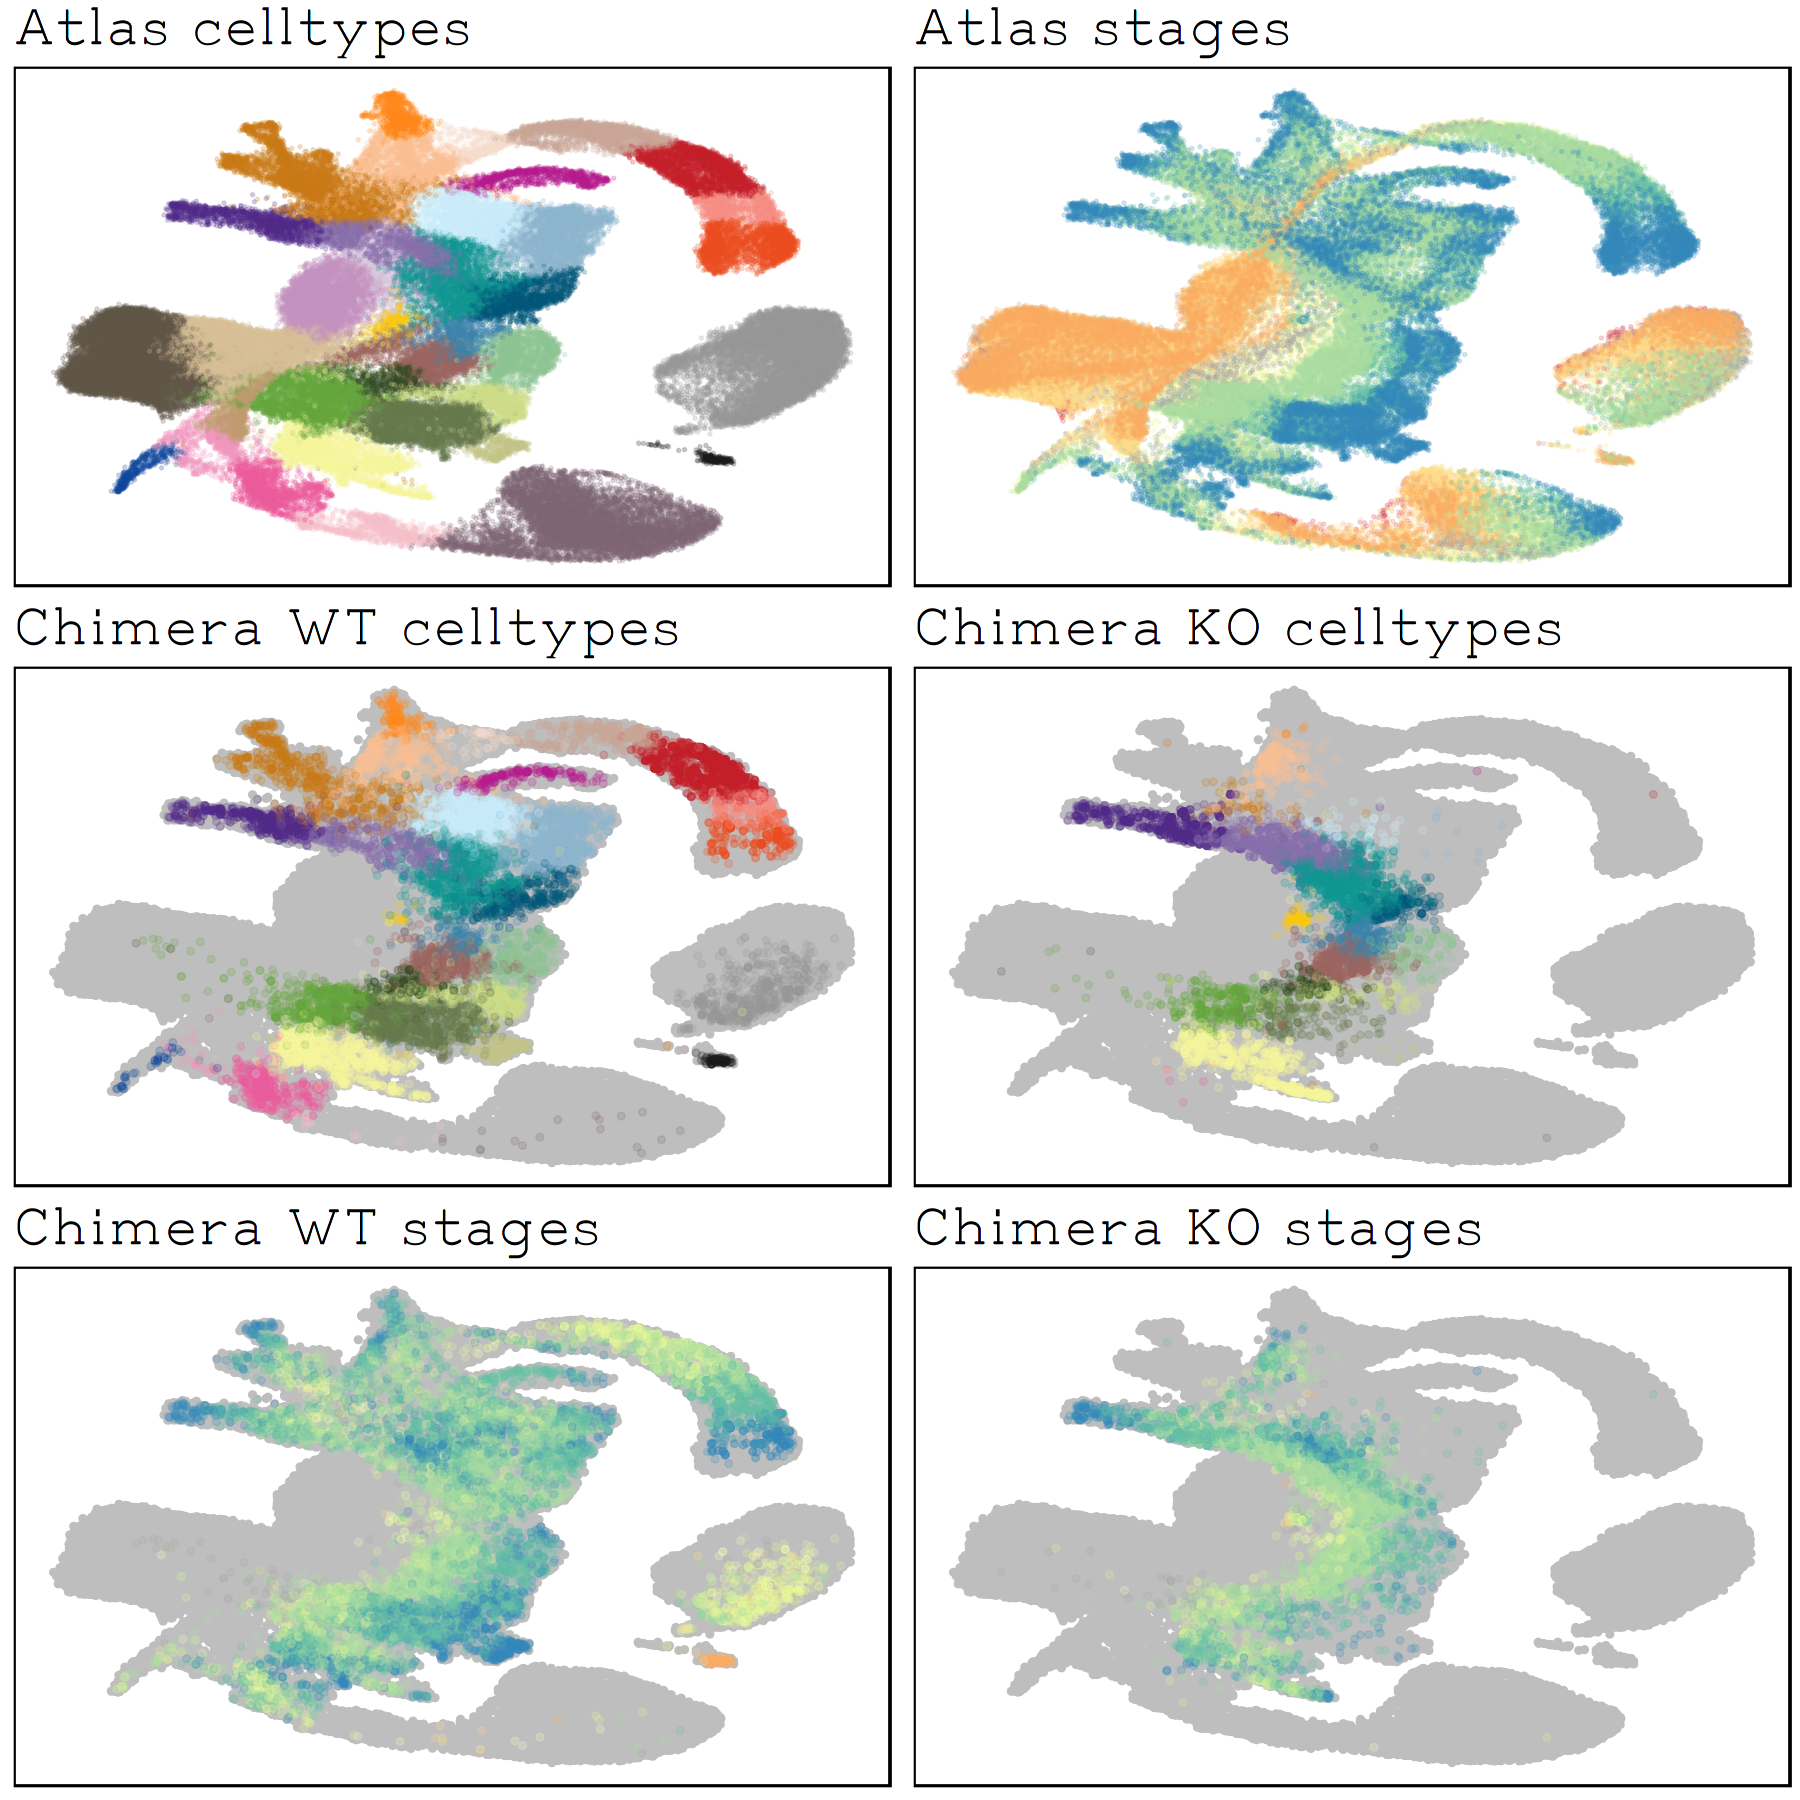

In [138]:
p1 = ggplot(atlas_meta, aes(umapX, umapY, col=celltype)) + 
    geom_point(alpha=0.2, size = 0.5) + 
    ggtitle('Atlas celltypes') + 
    scale_colour_manual(values = celltype_colours, name = "celltype") +
    umap_theme

p2 = ggplot(atlas_meta, aes(umapX, umapY, col=stage)) + 
    geom_point(alpha=0.2, size = 0.5) + 
    ggtitle('Atlas stages') + 
    scale_colour_manual(values = stage_colours, name = "Stage") +
    umap_theme

p3 = ggplot(big_meta[big_meta$tdTom=='negative',], aes(umapX.mapped, umapY.mapped, col=big_meta[big_meta$tdTom=='negative',]$celltype.mapped)) + 
    geom_point(data=big_meta[big_meta$exp=='atlas',], aes(umapX, umapY), col='grey') + 
    geom_point(alpha=0.2) + 
    ggtitle('Chimera WT celltypes') + 
    scale_colour_manual(values = celltype_colours, name = "celltype") +
    umap_theme

p4 = ggplot(big_meta[big_meta$tdTom=='positive',], aes(umapX.mapped, umapY.mapped, col=big_meta[big_meta$tdTom=='positive',]$celltype.mapped)) + 
    geom_point(data=big_meta[big_meta$exp=='atlas',], aes(umapX, umapY), col='grey') + 
    geom_point(alpha=0.2) + 
    ggtitle('Chimera KO celltypes') + 
    scale_colour_manual(values = celltype_colours, name = "celltype") +
    umap_theme

p5 = ggplot(big_meta[big_meta$tdTom=='negative',], aes(umapX.mapped, umapY.mapped, col=big_meta[big_meta$tdTom=='negative',]$stage.mapped)) + 
    geom_point(data=big_meta[big_meta$exp=='atlas',], aes(umapX, umapY), col='grey') + 
    geom_point(alpha=0.2) + 
    ggtitle('Chimera WT stages') + 
    scale_colour_manual(values = stage_colours, name = "Stage") +
    umap_theme

p6 = ggplot(big_meta[big_meta$tdTom=='positive',], aes(umapX.mapped, umapY.mapped, col=big_meta[big_meta$tdTom=='positive',]$stage.mapped)) + 
    geom_point(data=big_meta[big_meta$exp=='atlas',], aes(umapX, umapY), col='grey') + 
    geom_point(alpha=0.2) + 
    ggtitle('Chimera KO stages') + 
    scale_colour_manual(values = stage_colours, name = "Stage") +
    umap_theme

options(repr.plot.width=15, repr.plot.height=15)
grid.arrange(p1, p2, p3, p4, p5, p6, ncol=2)

In [139]:
ggsave(paste0(plot_dir, 'Atlas_projection.png'), 
       plot = grid.arrange(p1, p2, p3, p4, p5, p6, ncol=2), 
       device = 'png',
       width = 12,
       height = 15,
       dpi = 300)

Warning message:
“Removed 23019 rows containing missing values (geom_point).”
Warning message:
“Removed 23019 rows containing missing values (geom_point).”
Warning message:
“Removed 116312 rows containing missing values (geom_point).”
Warning message:
“Removed 116312 rows containing missing values (geom_point).”
Warning message:
“Removed 116312 rows containing missing values (geom_point).”
Warning message:
“Removed 116312 rows containing missing values (geom_point).”


In [2]:
sessionInfo()

R version 4.0.3 (2020-10-10)
Platform: x86_64-pc-linux-gnu (64-bit)
Running under: Manjaro Linux

Matrix products: default
BLAS:   /usr/local/lib64/R/lib/libRblas.so
LAPACK: /usr/local/lib64/R/lib/libRlapack.so

locale:
 [1] LC_CTYPE=en_GB.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_GB.UTF-8        LC_COLLATE=en_GB.UTF-8    
 [5] LC_MONETARY=en_GB.UTF-8    LC_MESSAGES=en_GB.UTF-8   
 [7] LC_PAPER=en_GB.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_GB.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] parallel  stats4    stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] gridExtra_2.3               dplyr_1.0.4.9000           
 [3] data.table_1.13.6           reticulate_1.18            
 [5] batchelor_1.6.2             scran_1.18.1               
 [7] knitr_1.30                  reshape2_1.4.4             
 [9] scater_1.18.3               